# **Project: Intel Image Classification using CNN**
**Problem Type**

**Multi-Class Image Classification**

**Classes**

The dataset contains 6 classes:


| Class     | Meaning           |
| --------- | ----------------- |
| Buildings | Urban buildings   |
| Forest    | Forest area       |
| Glacier   | Snow and glaciers |
| Mountain  | Mountains         |
| Sea       | Ocean/Sea         |
| Street    | Roads and streets |

# **STEP 1: Import Libraries**
**What happens here?**

We import all required libraries.

- TensorFlow → Deep Learning
- NumPy → Numerical Operations
- Matplotlib → Visualization
- Seaborn → Better Graphs

In [8]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# **STEP 2: Download Dataset from Kaggle**
**What happens here?**

We download Intel Image Classification dataset from Kaggle.

In [9]:
!mkdir -p /root/.kaggle
!cp "/content/drive/MyDrive/kaggle.json" /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [10]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:05<00:00, 61.3MB/s]



In [11]:
!unzip intel-image-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jp

In [17]:

train_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/seg_test/seg_test",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)
val_ds=tf.keras.preprocessing.image_dataset_from_directory("/content/seg_train/seg_train",validation_split=0.2,subset='training',seed=42, image_size=(128,128),batch_size=32)


Found 3000 files belonging to 6 classes.
Using 2400 files for training.
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, MaxPooling2D

In [19]:
normalization_layers = tf.keras.layers.Rescaling(1./255)

train_data = train_ds.map(lambda x, y : (normalization_layers(x), y))
val_data =val_ds.map(lambda x, y : (normalization_layers(x), y))

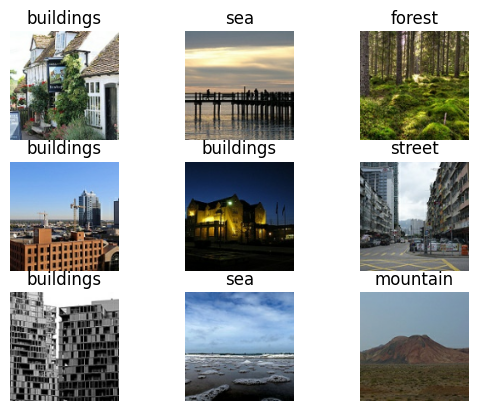

In [20]:
import matplotlib.pyplot as plt

class_names = train_ds.class_names

for images, labels in train_data.take(1):
  for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

In [21]:
from keras.src.layers import Conv2D
from keras.src.layers.pooling.max_pooling2d import MaxPooling2D
from keras.src.models.sequential import Sequential
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same', input_shape=(128, 128, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(len(class_names), activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [28]:
model.fit(
    train_data,
    validation_data = (val_ds),
    verbose = 1,
    epochs = 10
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.4296 - loss: 1.8483 - val_accuracy: 0.5867 - val_loss: 88.6970
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.5879 - loss: 0.9998 - val_accuracy: 0.6303 - val_loss: 96.1871
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - accuracy: 0.6525 - loss: 0.9251 - val_accuracy: 0.6022 - val_loss: 111.2521
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.6850 - loss: 0.8109 - val_accuracy: 0.6757 - val_loss: 89.5573
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.7496 - loss: 0.6788 - val_accuracy: 0.6237 - val_loss: 143.0564
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.7717 - loss: 0.6076 - val_accuracy: 0.6862 - val_loss: 131.6158
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - accuracy: 0.8279 - loss: 0.4743 - val_accuracy: 0.6797 - val_loss: 162.7883
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.8483 - loss: 0.4308 - va

In [36]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/seg_test/seg_test/sea/20077.jpg'
img = image.load_img(img_path, target_size = (128, 128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis = 0)

predicstions = model.predict(img_array)

predicted_class_idx = np.argmax(predicstions[0])

predicted_class_name = class_names[predicted_class_idx]

print(f"Predicted Class : {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted Class : sea


In [37]:
model.save('Intel Image Clasification.h5')